# Parte 1: Rompiendo ECB en Imágenes

- Utiliza una imagen BMP o PPM en escala de grises.
- Cifrar la imagen con AES en modo ECB y visualizar el resultado.
- Cifrar la misma imagen con AES en modo CBC y comparar.

In [1]:
import base64
from AES import *
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [2]:
# Usando funciones de ejercicio anterior
# Prueba Cifrado
key, iv = cipherImage_AES('./tests/tux.ppm/tux.ppm')
print(f"Llave generada: {base64.b64encode(key).decode('utf-8')}")
print(f"Vector de inicialización: {base64.b64encode(iv).decode('utf-8')}")
print("Imágenes cifradas guardadas como 'Images/image_ecb.png' y 'Images/image_cbc.png'")

Llave generada: Zj4X5VvJHY+cMhdpvDZqFQ==
Vector de inicialización: Ke5QQDGAhvnQl/htpQH8Tg==
Imágenes cifradas guardadas como 'Images/image_ecb.png' y 'Images/image_cbc.png'


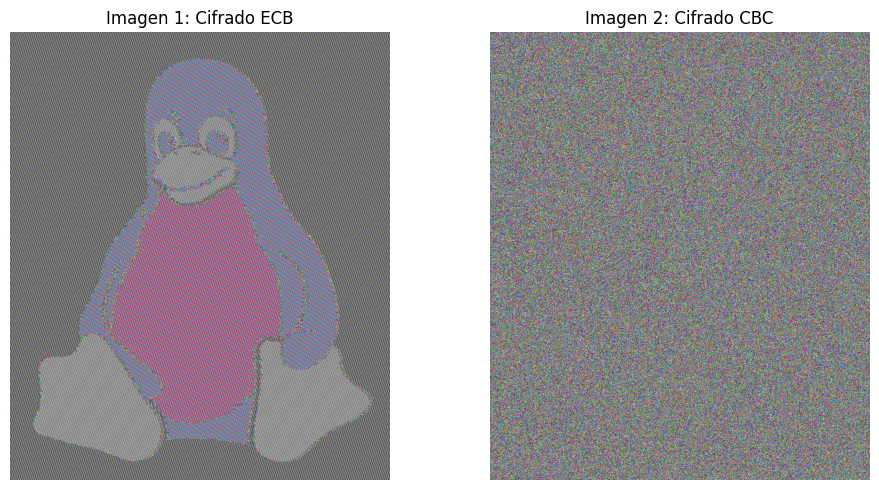

In [3]:
image1_path = "./Images/image_ecb.png"
image2_path = "./Images/image_cbc.png"

img1 = mpimg.imread(image1_path)
img2 = mpimg.imread(image2_path)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img1)
axes[0].set_title("Imagen 1: Cifrado ECB")
axes[0].axis("off") 

axes[1].imshow(img2)
axes[1].set_title("Imagen 2: Cifrado CBC")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## Preguntas para reflexión:

### ¿Por qué el cifrado ECB revela los patrones de la imagen?

R: La razón detrás de que el cifrado ECB revele la figura de la imagen, es que este modo de operación mantiene los patrones en los datos. Es decir, a pesar de que no podemos visualizar la imagen original en formato ppm, los patrones para mostrar la figura siguen ahí, los cuales se vuelven más evidentes mediante el cifrado con ECB. La razón de esto es que ECB cifra cada bloque de manera individual, utilizando únicamente la llave generada, lo cual no resulta efectivo para ocultar verdaderamente patrones en los datos.

### ¿Cómo cambia la apariencia con CBC?

R: Al utilizar CBC, se aprecia en el resultado una mezcla homogénea de pixeles sin ninguna silueta aparente. CBC, a diferencia de ECB, trabaja cifrando cada bloque tomando como referencia todos los bloques anteriores, por lo que el cifrado de un bloque _i_ dependerá del cifrado resultante de todos los bloques anteriores a _i_. Con este modo de operación, se logra ocultar los patrones en la imagen, y por lo tanto, volverla irreconocible.

### ¿Qué tan seguro es usar ECB para cifrar datos estructurados?

R: Nada seguro. Como se ha mencionado, ECB resulta poco efectivo a la hora de ocultar los patrones en los datos, por lo que al ser utilizado en datos estructurados dejaría vulnerabilidades explotables por cualquier atacante.